# Brain Tumor Classification with VGG16 (Fine-Tuning, two-phase)

Dataset: [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

This notebook follows the same pipeline structure as the EfficientNetB0/ResNet50/DenseNet121/MobileNetV3Large versions, using **VGG16** as the backbone with the same **two-phase transfer learning + fine-tuning** strategy (feature extraction first, then fine-tuning the top layers with a low learning rate).



In [2]:
import os
import numpy as np
import random
import json
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import shuffle
import matplotlib.pyplot as plt


In [3]:
train_dir = r"Dataset/archive/Training"
test_dir  = r"Dataset/archive/Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


In [4]:
# Define CLASS_LABELS ONCE using sorted() so order is always consistent
CLASS_LABELS = sorted(os.listdir(train_dir))
print("Class label order (fixed):", CLASS_LABELS)
print(f"Number of classes: {len(CLASS_LABELS)}")


Class label order (fixed): ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


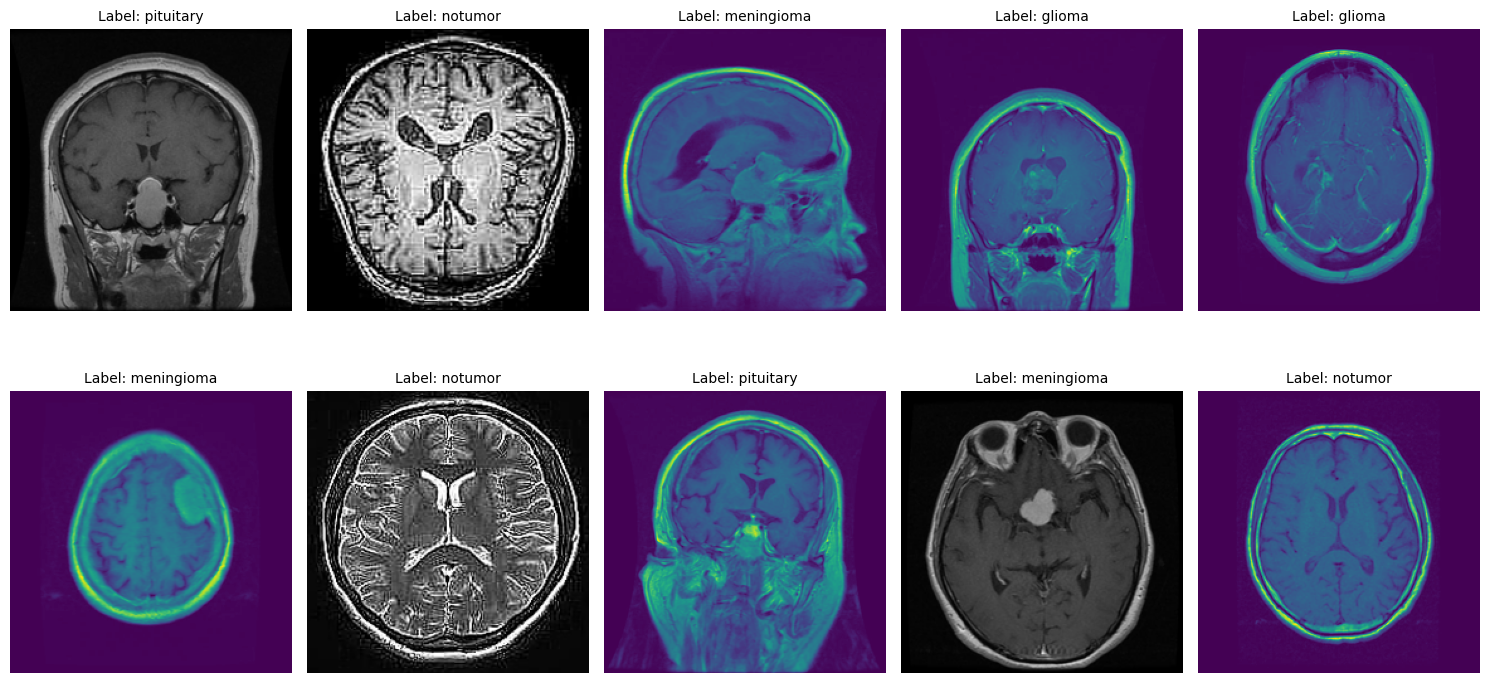

In [5]:
# Visualize some training samples
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img = Image.open(train_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


## Image loading & augmentation

VGG16 expects images sized **224x224** and preprocessed with its own `preprocess_input` (it converts RGB to BGR and subtracts the ImageNet mean per channel, no [0, 1] scaling) — **do not** manually rescale to [0, 1] on top of it.

In [6]:
IMAGE_SIZE = 224  # VGG16 default input size

# Image Augmentation
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image)
    return image

# Load images (kept in raw 0-255 range; preprocess_input handles normalization)
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image)
        image = augment_image(image)
        images.append(image)
    images = np.array(images)
    return preprocess_input(images)


def encode_label(labels):
    return np.array([CLASS_LABELS.index(label) for label in labels])

# Data generator
def datagen(paths, labels, batch_size=20, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths  = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(labels[i:i + batch_size])
            yield batch_images, batch_labels


## Build the model

**Phase 1 — Feature extraction:** freeze the entire VGG16 backbone and train only the new classification head.

**Phase 2 — Fine-tuning:** unfreeze the top block(s) of the backbone and continue training with a much smaller learning rate, so the pretrained ImageNet features are nudged toward MRI features instead of being destroyed. VGG16 is a simple stack of conv blocks (no residual/dense connections), so we unfreeze the last conv block (`block5`), matching the 3-layer unfreeze used in the original single-phase version, but now done properly in a separate low-LR phase.

In [7]:
# Build Model
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Phase 1: freeze the entire backbone
base_model.trainable = False

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(CLASS_LABELS), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,916 (56.39 MB)

 Trainable params: 67,204 (262.52 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

### Phase 1 training — train the classification head only

In [8]:
# Train the Model (Phase 1: frozen backbone)
batch_size = 20
epochs_phase1 = 5
steps = int(len(train_paths) / batch_size)

history1 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase1),
    epochs=epochs_phase1,
    steps_per_epoch=steps
)


Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1927s 7s/step - loss: 0.8251 - sparse_categorical_accuracy: 0.7011
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1941s 7s/step - loss: 0.3792 - sparse_categorical_accuracy: 0.8538
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1701s 6s/step - loss: 0.3057 - sparse_categorical_accuracy: 0.8866
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1510s 5s/step - loss: 0.2364 - sparse_categorical_accuracy: 0.9082
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1037s 4s/step - loss: 0.2263 - sparse_categorical_accuracy: 0.9172


### Phase 2 training — unfreeze top layers and fine-tune

Unfreeze VGG16's last conv block (`block5_conv1/2/3` + `block5_pool`) — the same layers targeted in the original single-phase version — and continue training with a low learning rate.

In [9]:
# Phase 2: unfreeze the top layers of the backbone for fine-tuning
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 4  # unfreeze last 4 layers (block5: 3 conv + pool)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# VGG16 has no BatchNorm layers in its standard Keras implementation, so no BN-freezing step is
# needed here (unlike ResNet50/DenseNet121/MobileNetV3Large)

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,916 (56.39 MB)

 Trainable params: 7,146,628 (27.26 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

In [10]:
epochs_phase2 = 10

callbacks = [
    EarlyStopping(monitor='loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase2),
    epochs=epochs_phase2,
    steps_per_epoch=steps,
    callbacks=callbacks
)


Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 25732s 92s/step - loss: 0.1776 - sparse_categorical_accuracy: 0.9323 - learning_rate: 1.0000e-05
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 2867s 10s/step - loss: 0.1091 - sparse_categorical_accuracy: 0.9630 - learning_rate: 1.0000e-05
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1458s 5s/step - loss: 0.0687 - sparse_categorical_accuracy: 0.9778 - learning_rate: 1.0000e-05
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1659s 6s/step - loss: 0.0544 - sparse_categorical_accuracy: 0.9845 - learning_rate: 1.0000e-05
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 2373s 8s/step - loss: 0.0371 - sparse_categorical_accuracy: 0.9901 - learning_rate: 1.0000e-05
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1666s 6s/step - loss: 0.0298 - sparse_categorical_accuracy: 0.9935 - learning_rate: 1.0000e-05
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1559s 6s/step - loss: 0.0253 - sparse_categorical_accuracy: 0.9953 - learning_rate: 1.0000e-05
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1201s 4s/ste

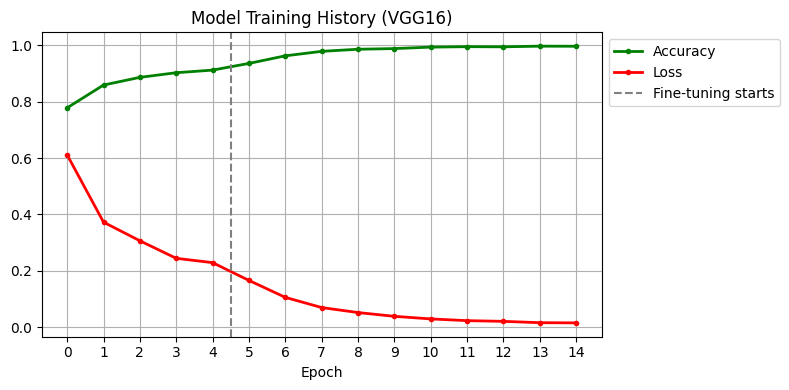

In [11]:
# Combine history from both phases for plotting
acc = history1.history['sparse_categorical_accuracy'] + history2.history['sparse_categorical_accuracy']
loss = history1.history['loss'] + history2.history['loss']
total_epochs = epochs_phase1 + len(history2.history['loss'])

plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(acc, '.g-', linewidth=2)
plt.plot(loss, '.r-', linewidth=2)
plt.axvline(x=epochs_phase1 - 0.5, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Model Training History (VGG16)')
plt.xlabel('Epoch')
plt.xticks(range(total_epochs))
plt.legend(['Accuracy', 'Loss', 'Fine-tuning starts'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [12]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on test data
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)
predicted_classes = np.argmax(test_predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, predicted_classes, target_names=CLASS_LABELS))


50/50 ━━━━━━━━━━━━━━━━━━━━ 306s 6s/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.81      0.88       400
  meningioma       0.90      0.94      0.92       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



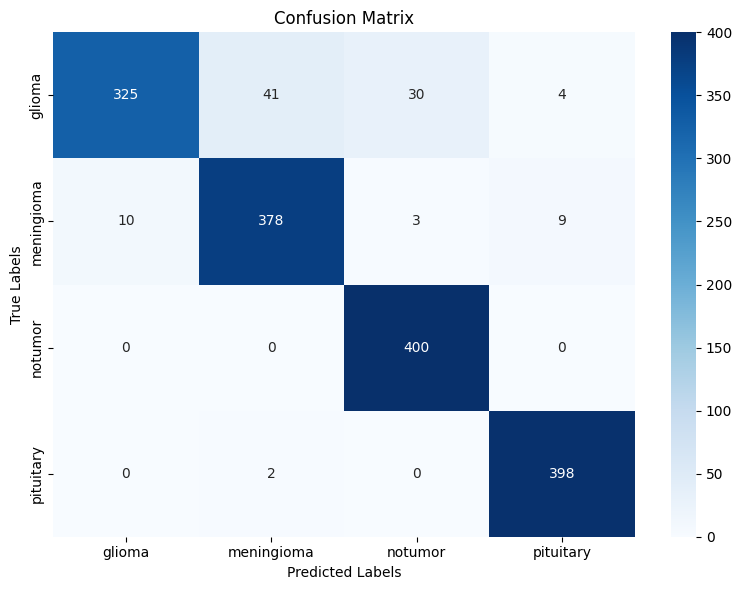

In [13]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


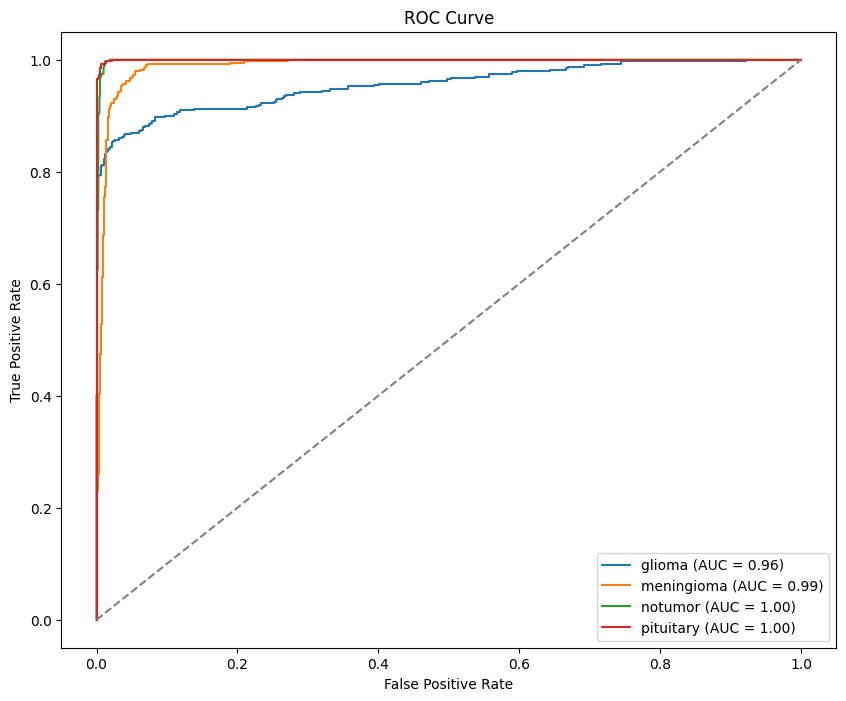

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC Curve
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(CLASS_LABELS)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(CLASS_LABELS)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(CLASS_LABELS)):
    plt.plot(fpr[i], tpr[i], label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [15]:
# Save the model
model.save('model_vgg16_v2.h5')
print("Model saved as model_vgg16_v2.h5")

# Also save CLASS_LABELS so you can load them later without retraining
with open('class_labels.json', 'w') as f:
    json.dump(CLASS_LABELS, f)
print("Class labels saved as class_labels.json:", CLASS_LABELS)


Model saved as model_vgg16_v2.h5
Class labels saved as class_labels.json: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [16]:
# Load model (optional — run only if restarting kernel)
model = load_model('model_vgg16_v2.h5')

with open('class_labels.json') as f:
    CLASS_LABELS = json.load(f)

print("Model loaded. Class labels:", CLASS_LABELS)


Model loaded. Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
# Prediction function
def detect_and_display(img_path, model, image_size=224):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0]

        predicted_label = CLASS_LABELS[predicted_index]

        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        # Show all class probabilities
        print("Probabilities:")
        for i, label in enumerate(CLASS_LABELS):
            print(f"  {label}: {predictions[0][i]*100:.2f}%")

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 0.00%
  notumor: 100.00%
  pituitary: 0.00%


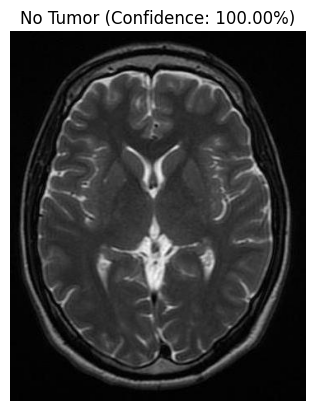

In [18]:
# Test prediction — No Tumor
image_path = r'Dataset/archive/Testing/notumor/Te-no_4.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 0.00%
  notumor: 0.00%
  pituitary: 100.00%


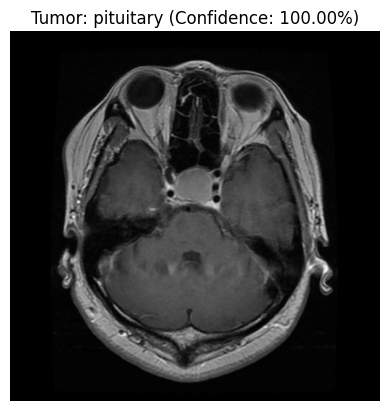

In [19]:
# Test prediction — Pituitary Tumor
image_path = r'Dataset/archive/Training/pituitary/Tr-pi_3.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 99.12%
  notumor: 0.78%
  pituitary: 0.10%


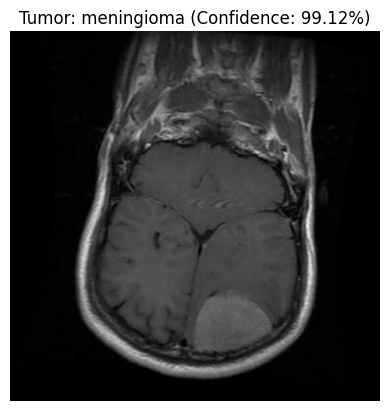

In [20]:
# Test prediction — Meningioma Tumor
image_path = r'Dataset/archive/Training/meningioma/Tr-aug-me_2.jpg'
detect_and_display(image_path, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 0.00%
  notumor: 0.00%
  pituitary: 100.00%


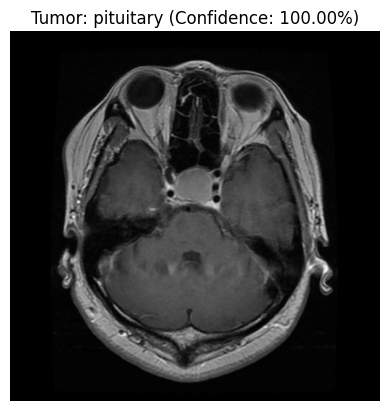

In [21]:
# Test prediction — Pituitary Tumor
image_path = r'Dataset/archive/Training/pituitary/Tr-pi_3.jpg'
detect_and_display(image_path, model)
